In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import torch

from train import Trainer, TrainingConfig
from train.models import LowRankRateRNN
from sklearn.decomposition import PCA

print("Imports OK")
print(f"PyTorch {torch.__version__}")
if torch.backends.mps.is_available():
    print("Device: MPS (Apple GPU)")
elif torch.cuda.is_available():
    print(f"Device: CUDA ({torch.cuda.get_device_name(0)})")
else:
    print("Device: CPU")

Imports OK
PyTorch 2.10.0
Device: MPS (Apple GPU)


In [2]:
# Load dataset — NEXT-STEP PREDICTION
#
# X[:, :-1, :] = observed partial rates at time t      (input)
# Y[:, 1:,  :] = full rates at time t+1                (target)
#
# Lesson from vanilla RNN experiments:
#   Same-timestep reconstruction (X[t] → Y[t]) lets the model solve the task
#   without temporal dynamics. At 100% obs, X==Y, so the loss goes to zero
#   trivially. Next-step prediction forces the model to learn the ring's
#   temporal evolution — the only way to predict where the bump will be next
#   is to internalize ring attractor dynamics.

data = np.load("../data/shared_ring_dataset.npz", allow_pickle=True)

OBS_LEVELS = {
    "100%": ("X_rates_obs_100", 1.0),
    "50%":  ("X_rates_obs_50",  0.5),
    "25%":  ("X_rates_obs_25",  0.25),
    "10%":  ("X_rates_obs_10",  0.1),
}

Y       = data["Y_rates"]    # (140, 1000, 100)
Y_theta = data["Y_theta"]    # (140, 1000)
train_idx = data["train_idx"]
test_idx  = data["test_idx"]

# Pre-shift targets once — reused in every obs-level loop
Y_out       = Y[:, 1:, :]          # target: t+1,  shape (140, 999, 100)
Y_theta_out = Y_theta[:, 1:]        # theta aligned with Y_out
Y_theta_test = Y_theta_out[test_idx]

print(f"Y_out shape:        {Y_out.shape}  (trials, bins-1, neurons)")
print(f"Train trials: {len(train_idx)}   Test trials: {len(test_idx)}")
print(f"Obs levels:   {list(OBS_LEVELS.keys())}")

Y_out shape:        (140, 999, 100)  (trials, bins-1, neurons)
Train trials: 112   Test trials: 28
Obs levels:   ['100%', '50%', '25%', '10%']


In [3]:
# Training config
# rank=2 because the ring attractor's cosine-kernel connectivity is exactly rank-2
# (W_ij = J0 + J1*cos(theta_i - theta_j) = J0 + J1*(cos_i*cos_j + sin_i*sin_j))
# A rank-2 LowRankRNN can represent this exactly; higher rank gives no benefit.
# alpha=0.5 gives stronger recurrence than the default 0.1.

train_config = TrainingConfig(
    model_type="lowrank",
    hidden_dim=100,
    alpha=0.5,
    rank=2,
    learning_rate=1e-3,
    n_epochs=2000,
    clip_grad=1.0,
    checkpoint_dir="../checkpoints/lowrank_nextstep",
    checkpoint_every=50,
    keep_last_n=3,
    log_every=25,
    device="auto",
)

print(train_config)

TrainingConfig(model_type='lowrank', hidden_dim=100, alpha=0.5, rank=2, learning_rate=0.001, n_epochs=2000, clip_grad=1.0, checkpoint_dir='../checkpoints/lowrank_nextstep', checkpoint_every=50, keep_last_n=3, log_every=25, device='auto')


In [ ]:
# Train all observation levels
results = {}

for label, (x_key, obs_frac) in OBS_LEVELS.items():
    print(f"\n{'='*55}")
    print(f"Observation level: {label}")
    print(f"{'='*55}")

    X = data[x_key]               # (140, 1000, k_neurons)
    X_in = X[:, :-1, :]           # input: t=0..998

    trainer = Trainer(train_config)
    result = trainer.train(
        X_train=X_in[train_idx],
        Y_train=Y_out[train_idx],
        X_test=X_in[test_idx],
        Y_test=Y_out[test_idx],
        Y_theta_test=Y_theta_test,
        observation_level=obs_frac,
    )

    results[label] = result


Observation level: 100%
Training lowrank RNN on mps
  Input dim: 100, Hidden dim: 100, Output dim: 100
  Epochs: 0 -> 2000

  Epoch    1/2000  train_loss=7.905404  test_loss=7.389949  *best*


In [5]:
# ── Reload results from checkpoints (run this instead of cell 3 after a kernel reset) ─
#
# Prerequisites: run cells 0 (imports), 1 (load data), 2 (training config) first.
# This reconstructs `results` by loading the best saved checkpoint for each obs level
# and re-running inference on the test set.

from pathlib import Path
from train.checkpoint import load_checkpoint
from train.models import create_model
from train.trainer import TrainingResult, decode_angle, circular_angle_error

CHECKPOINT_DIR = Path(train_config.checkpoint_dir)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
criterion = torch.nn.MSELoss()

results = {}

for label, (x_key, obs_frac) in OBS_LEVELS.items():
    obs_pct   = int(obs_frac * 100)
    best_ckpt = CHECKPOINT_DIR / f"lowrank_obs{obs_pct}_best.pt"

    if not best_ckpt.exists():
        print(f"[{label}]  ✗  no checkpoint at {best_ckpt} — skipping")
        continue

    X    = data[x_key]
    X_in = X[:, :-1, :]          # (trials, 999, obs_neurons)

    input_dim  = X_in.shape[-1]
    output_dim = Y_out.shape[-1]  # always 100 (full population)

    model = create_model(
        model_type=train_config.model_type,
        input_dim=input_dim,
        hidden_dim=train_config.hidden_dim,
        output_dim=output_dim,
        alpha=train_config.alpha,
        rank=train_config.rank,
    ).to(device)

    ckpt_state = load_checkpoint(best_ckpt, model)   # loads weights in-place
    model.eval()

    with torch.no_grad():
        X_test_t  = torch.tensor(X_in[test_idx],  dtype=torch.float32, device=device)
        Y_test_t  = torch.tensor(Y_out[test_idx], dtype=torch.float32, device=device)
        X_train_t = torch.tensor(X_in[train_idx], dtype=torch.float32, device=device)
        Y_train_t = torch.tensor(Y_out[train_idx],dtype=torch.float32, device=device)

        y_pred_test,  h_test = model(X_test_t)
        y_pred_train, _      = model(X_train_t)

        final_test_mse  = criterion(y_pred_test,  Y_test_t).item()
        final_train_mse = criterion(y_pred_train, Y_train_t).item()

    y_pred_np  = y_pred_test.cpu().numpy()
    theta_pred = decode_angle(y_pred_np)
    angle_err  = circular_angle_error(theta_pred, Y_theta_test)

    results[label] = TrainingResult(
        model=model,
        train_losses=ckpt_state.train_losses,
        test_losses=ckpt_state.test_losses,
        final_train_mse=final_train_mse,
        final_test_mse=final_test_mse,
        angle_error=angle_err,
        epochs_trained=ckpt_state.epoch,
        training_time=0.0,
        hidden_states_test=h_test.cpu().numpy(),
        predictions_test=y_pred_np,
        theta_pred_test=theta_pred,
    )

    print(f"[{label}]  epoch {ckpt_state.epoch:4d}  "
          f"test_mse={final_test_mse:.6f}  angle_err={np.degrees(angle_err):.2f}°")

print(f"\nLoaded {len(results)}/{len(OBS_LEVELS)} observation levels.")

[100%]  epoch 1800  test_mse=1.461764  angle_err=14.48°
[50%]  epoch 1900  test_mse=1.644371  angle_err=16.80°
[25%]  epoch 1850  test_mse=1.800327  angle_err=19.28°
[10%]  ✗  no checkpoint at ../checkpoints/lowrank_nextstep/lowrank_obs10_best.pt — skipping

Loaded 3/4 observation levels.


In [6]:
# Summary table
import pandas as pd

rows = []
for label, r in results.items():
    rows.append({
        "obs_level":     label,
        "train_mse":     f"{r.final_train_mse:.6f}",
        "test_mse":      f"{r.final_test_mse:.6f}",
        "angle_err_deg": f"{np.degrees(r.angle_error):.2f}",
        "train_time_s":  f"{r.training_time:.1f}",
    })

pd.DataFrame(rows)

,obs_level,train_mse,test_mse,angle_err_deg,train_time_s
0,100%,1.456421,1.461764,14.48,0.0
1,50%,1.645913,1.644371,16.80,0.0
2,25%,1.795348,1.800327,19.28,0.0


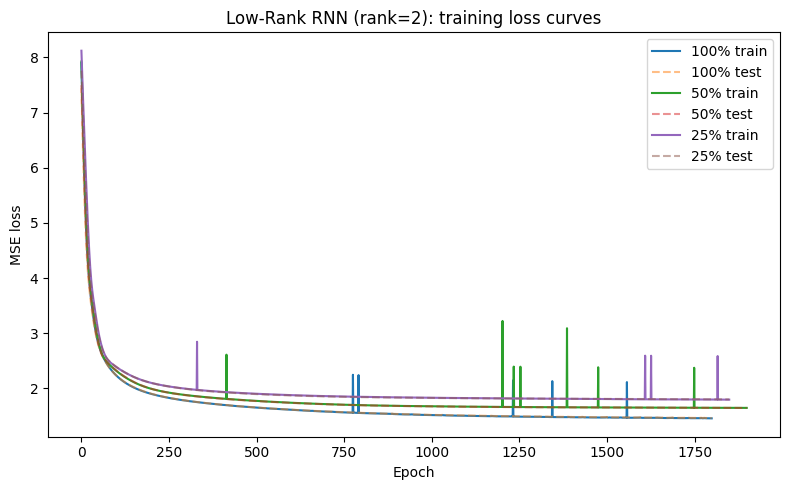

In [7]:
# Training loss curves
plt.figure(figsize=(8, 5))
for label, r in results.items():
    plt.plot(r.train_losses, label=f"{label} train")
    plt.plot(r.test_losses,  label=f"{label} test", linestyle="--", alpha=0.5)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Low-Rank RNN (rank=2): training loss curves")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# MSE and angle error vs observed fraction
obs_numeric    = [100, 50, 25, 10]
test_mse_vals  = [results[k].final_test_mse for k in OBS_LEVELS]
angle_err_vals = [results[k].angle_error    for k in OBS_LEVELS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(obs_numeric, test_mse_vals, marker="o")
ax1.invert_xaxis()
ax1.set_xlabel("Observed neurons (%)")
ax1.set_ylabel("Test MSE")
ax1.set_title("Rate reconstruction vs observed neurons")

ax2.plot(obs_numeric, np.degrees(angle_err_vals), marker="o", color="orange")
ax2.invert_xaxis()
ax2.set_xlabel("Observed neurons (%)")
ax2.set_ylabel("Mean angle error (°)")
ax2.set_title("Angle decoding error vs observed neurons")

plt.suptitle("Low-Rank RNN (rank=2) — observation level summary")
plt.tight_layout()
plt.show()

KeyError: '10%'

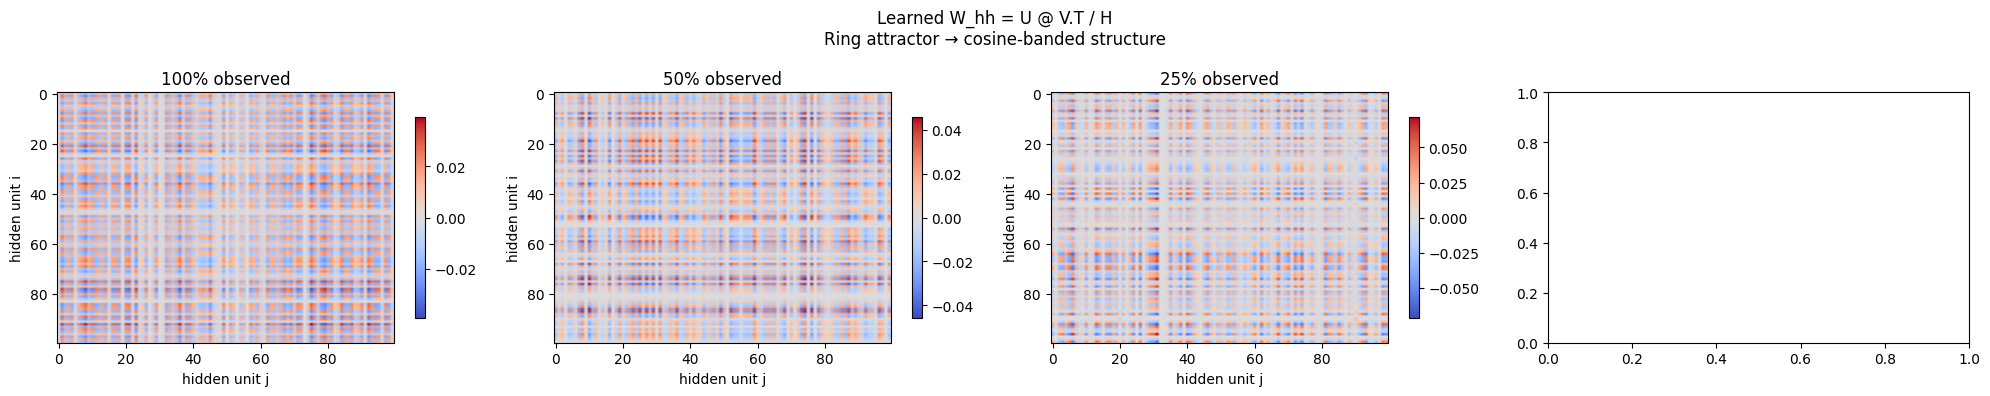

In [9]:
# Low-rank diagnostic 1: W_hh heatmap
# For a rank-2 ring attractor, W_hh should look like a cosine-kernel:
# W_ij ∝ cos(theta_i - theta_j)  — a smooth banded structure.
# If we recover that, the model has learned the right mechanism.

fig, axes = plt.subplots(1, len(OBS_LEVELS), figsize=(5 * len(OBS_LEVELS), 4))

for ax, (label, r) in zip(axes, results.items()):
    W_hh = r.model.get_recurrent_weights()  # (hidden_dim, hidden_dim)
    im = ax.imshow(W_hh, aspect="auto", cmap="coolwarm",
                   vmin=-np.abs(W_hh).max(), vmax=np.abs(W_hh).max())
    ax.set_title(f"{label} observed")
    ax.set_xlabel("hidden unit j")
    ax.set_ylabel("hidden unit i")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Learned W_hh = U @ V.T / H\nRing attractor → cosine-banded structure")
plt.tight_layout()
plt.show()

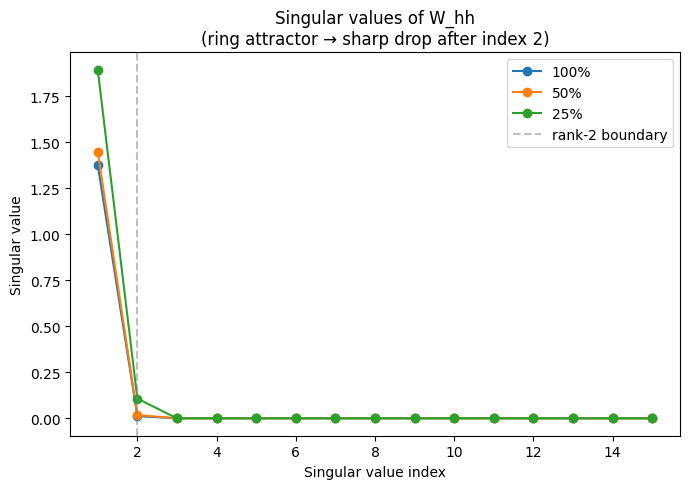

In [10]:
# Low-rank diagnostic 2: singular values of W_hh
# A rank-2 ring attractor has exactly 2 non-zero singular values.
# We expect the 100% model to show a sharp drop after index 2,
# and lower-obs models to show a more gradual drop (smeared out by ambiguity).

plt.figure(figsize=(7, 5))
for label, r in results.items():
    svals = r.model.get_singular_values()[:15]
    plt.plot(np.arange(1, len(svals) + 1), svals, marker="o", label=label)

plt.axvline(x=2, color="gray", linestyle="--", alpha=0.5, label="rank-2 boundary")
plt.xlabel("Singular value index")
plt.ylabel("Singular value")
plt.title("Singular values of W_hh\n(ring attractor → sharp drop after index 2)")
plt.legend()
plt.tight_layout()
plt.show()

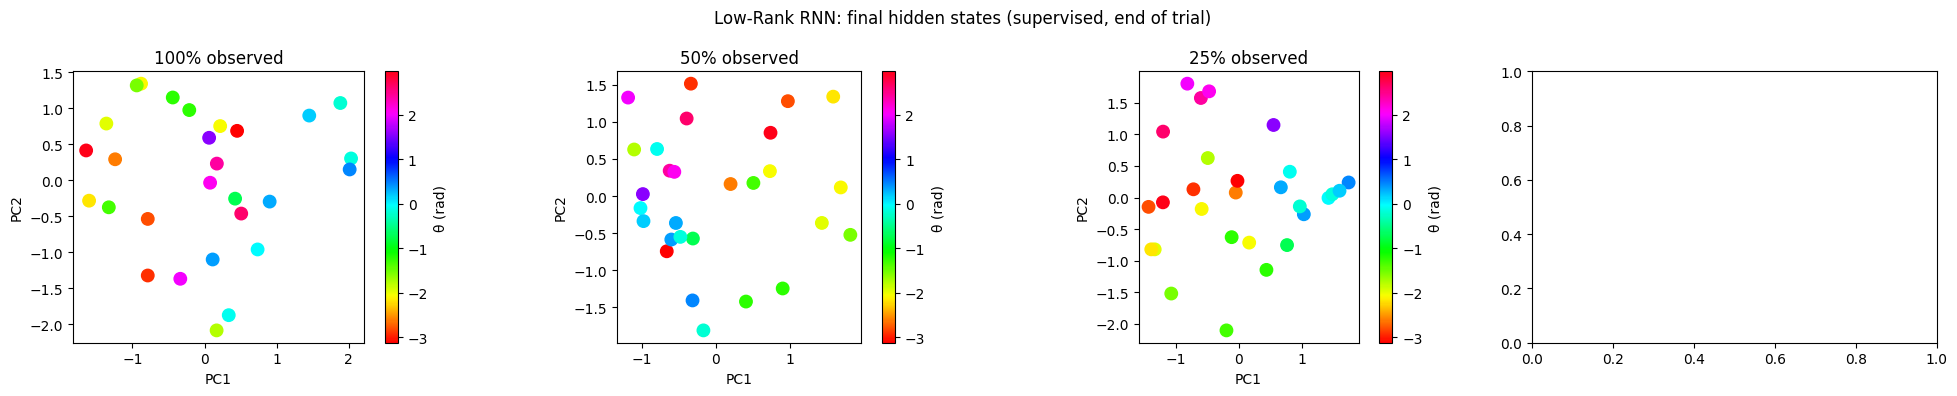

In [11]:
# Supervised PCA: final hidden states of test trials, coloured by theta
# (same as vanilla notebook — context, not the primary ring test)

fig, axes = plt.subplots(1, len(OBS_LEVELS), figsize=(5 * len(OBS_LEVELS), 4))

for ax, (label, r) in zip(axes, results.items()):
    h_last     = r.hidden_states_test[:, -1, :]   # (n_test, hidden_dim)
    theta_last = Y_theta_test[:, -1]              # (n_test,)

    pca = PCA(n_components=2)
    h_pca = pca.fit_transform(h_last)

    sc = ax.scatter(h_pca[:, 0], h_pca[:, 1], c=theta_last, cmap="hsv", s=80)
    ax.set_title(f"{label} observed")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, label="θ (rad)")

plt.suptitle("Low-Rank RNN: final hidden states (supervised, end of trial)")
plt.tight_layout()
plt.show()

In [12]:
# Fixed-point analysis — the primary ring attractor test
#
# Run the model AUTONOMOUSLY (zero input) from 300 random initial states.
# Ring attractor → all trajectories converge to a CIRCLE in hidden space.
# Discrete attractor → trajectories converge to isolated blobs.
# No attractor → trajectories diverge or collapse to origin.

def run_autonomous(model, n_init=300, n_steps=500, h_scale=0.5):
    model.eval()
    device = next(model.parameters()).device
    h0     = torch.randn(n_init, model.hidden_dim, device=device) * h_scale
    x_zero = torch.zeros(n_init, n_steps, model.input_dim, device=device)
    with torch.no_grad():
        y_traj, h_traj = model(x_zero, h0=h0)
    return (
        h_traj[:, -1, :].cpu().numpy(),  # converged hidden states
        y_traj[:, -1, :].cpu().numpy(),  # readout at convergence
    )

print("run_autonomous() defined.")

run_autonomous() defined.


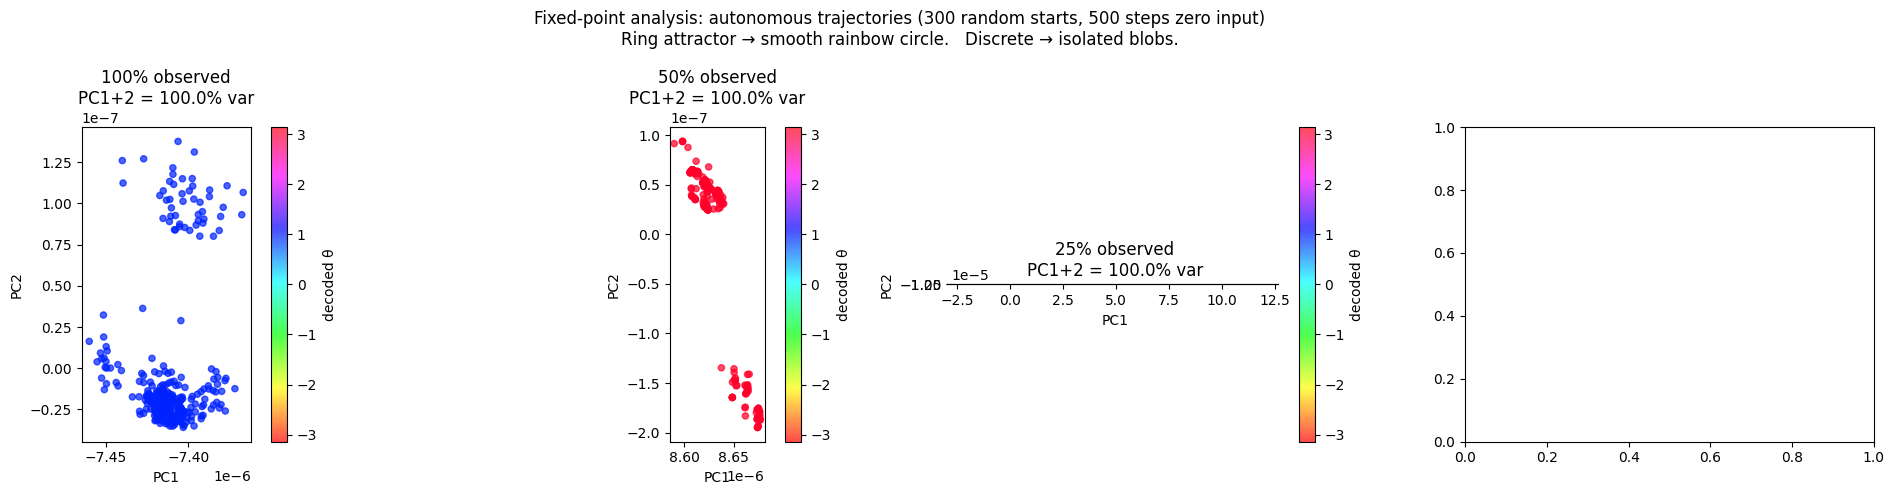

In [13]:
# Fixed-point PCA plot
fp_results = {}

fig, axes = plt.subplots(1, len(OBS_LEVELS), figsize=(5 * len(OBS_LEVELS), 5))

for ax, (label, r) in zip(axes, results.items()):
    h_final, y_final = run_autonomous(r.model, n_init=300, n_steps=500)

    # Decode angle from readout at convergence
    angles = np.linspace(0, 2 * np.pi, y_final.shape[-1], endpoint=False)
    x_pop  = (y_final * np.cos(angles)).sum(axis=1)
    y_pop  = (y_final * np.sin(angles)).sum(axis=1)
    theta_conv = np.arctan2(y_pop, x_pop)

    pca = PCA(n_components=2)
    h_pca = pca.fit_transform(h_final)
    var_explained = pca.explained_variance_ratio_[:2].sum()

    sc = ax.scatter(h_pca[:, 0], h_pca[:, 1],
                    c=theta_conv, cmap="hsv", s=20, alpha=0.7,
                    vmin=-np.pi, vmax=np.pi)
    ax.set_title(f"{label} observed\nPC1+2 = {var_explained:.1%} var")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, label="decoded θ")

    fp_results[label] = dict(h_final=h_final, y_final=y_final,
                              theta_conv=theta_conv, h_pca=h_pca,
                              var_explained=var_explained)

plt.suptitle("Fixed-point analysis: autonomous trajectories (300 random starts, 500 steps zero input)\n"
             "Ring attractor → smooth rainbow circle.   Discrete → isolated blobs.")
plt.tight_layout()
plt.show()

In [14]:
# Ring score table
#
# spread:      mean L2 norm of converged states. Near zero = collapsed to origin.
# uniformity:  1 - mean_resultant_length. 1 = angles uniform (ring). 0 = all same angle.
# circularity: aspect ratio of 2D PCA cloud. 1 = circle. 0 = line.

rows = []
for label, fp in fp_results.items():
    spread      = np.linalg.norm(fp["h_final"], axis=1).mean()
    R           = np.abs(np.exp(1j * fp["theta_conv"]).mean())
    uniformity  = 1 - R
    h_pca       = fp["h_pca"]
    circularity = min(h_pca[:,0].std(), h_pca[:,1].std()) / \
                  (max(h_pca[:,0].std(), h_pca[:,1].std()) + 1e-8)

    note = ""
    if spread < 0.05:
        note = "← collapsed to origin"
    elif uniformity > 0.7 and circularity > 0.5:
        note = "✓ RING"
    elif uniformity > 0.4:
        note = "~ partial ring"
    else:
        note = "← discrete fixed points"

    rows.append(dict(obs_level=label,
                     spread=f"{spread:.3f}",
                     uniformity=f"{uniformity:.3f}",
                     circularity=f"{circularity:.3f}",
                     var_2d=f"{fp['var_explained']:.1%}",
                     verdict=note))
    print(f"{label:5s}  spread={spread:.3f}  uniformity={uniformity:.3f}  "
          f"circularity={circularity:.3f}  {note}")

import pandas as pd
pd.DataFrame(rows)

100%   spread=3.022  uniformity=0.000  circularity=0.290  ← discrete fixed points
50%    spread=4.173  uniformity=0.000  circularity=0.211  ← discrete fixed points
25%    spread=7.408  uniformity=0.014  circularity=0.000  ← discrete fixed points


,obs_level,spread,uniformity,circularity,var_2d,verdict
0,100%,3.022,0.000,0.290,100.0%,← discrete fixed points
1,50%,4.173,0.000,0.211,100.0%,← discrete fixed points
2,25%,7.408,0.014,0.000,100.0%,← discrete fixed points
